# Step 3: NLP Annotation (F3)

Abraham Tedla (wqp7qy@virginia.edu)  
DS 5001  
April 2026

Annotate TOKEN and VOCAB with stopwords, stems, lemmas, and NRC sentiment/emotion scores.

# Set Up

In [49]:
import pandas as pd
import numpy as np
import os

np.random.seed(42)

In [50]:
import seaborn as sns
sns.set()
%matplotlib inline

In [51]:
output_dir = 'output'

OHCO = ['book_id', 'chapter', 'para_num', 'sent_num']
BOOKS = OHCO[:1]
CHAPS = OHCO[:2]
PARAS = OHCO[:3]
SENTS = OHCO[:4]

emo_cols = 'anger anticipation disgust fear joy sadness surprise trust'.split()
sent_cols = 'negative positive'.split()
all_nrc_cols = sent_cols + emo_cols

# Load F2 Data

In [52]:
TOKEN = pd.read_csv(os.path.join(output_dir, 'TOKEN.csv')).set_index(OHCO + ['token_num']).sort_index()
VOCAB = pd.read_csv(os.path.join(output_dir, 'VOCAB.csv')).set_index('term_str')
LIBRARY = pd.read_csv(os.path.join(output_dir, 'LIBRARY.csv')).set_index('book_id').sort_index()

In [53]:
TOKEN.head()

token_str      term_str  pos  \
book_id chapter para_num sent_num token_num                                    
35      1       0        0        0          Introduction  introduction   NN   
                1        0        0                   The           the   DT   
                                  1                  Time          time  NNP   
                                  2             Traveller     traveller  NNP   
                                  3                   for           for   IN   

                                             term_id  
book_id chapter para_num sent_num token_num           
35      1       0        0        0             4713  
                1        0        0                0  
                                  1               71  
                                  2             1169  
                                  3               19

In [54]:
VOCAB.head()

,n,df,max_pos,term_id
term_str,,,,
the,51573,12,DT,0
and,29951,12,CC,1
of,26564,12,IN,2
i,24740,12,PRP,3
to,22596,12,TO,4


# Stopwords

In [55]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [56]:
VOCAB['stop'] = VOCAB.index.isin(stop_words).astype(int)
print(f"Stopwords in vocab: {VOCAB['stop'].sum()} / {len(VOCAB)}")

Stopwords in vocab: 153 / 25122


In [57]:
# Add to TOKEN via join
TOKEN = TOKEN.join(VOCAB[['stop']], on='term_str')
TOKEN.head()

token_str      term_str  pos  \
book_id chapter para_num sent_num token_num                                    
35      1       0        0        0          Introduction  introduction   NN   
                1        0        0                   The           the   DT   
                                  1                  Time          time  NNP   
                                  2             Traveller     traveller  NNP   
                                  3                   for           for   IN   

                                             term_id  stop  
book_id chapter para_num sent_num token_num                 
35      1       0        0        0             4713     0  
                1        0        0                0     1  
                                  1               71     0  
                                  2             1169     0  
                                  3               19     1

# Stemming (Porter)

In [58]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

In [59]:
VOCAB['stem'] = VOCAB.index.map(lambda x: stemmer.stem(x))
VOCAB[['stem', 'n']].head(20)

,stem,n
term_str,,
the,the,51573
and,and,29951
of,of,26564
i,i,24740
to,to,22596
a,a,18147
in,in,13074
that,that,11537
was,wa,11170


# Lemmatization

In [60]:
nltk.download('wordnet', quiet=True)
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [61]:
VOCAB['lemma'] = VOCAB.index.map(lambda x: lemmatizer.lemmatize(x))
VOCAB[['stem', 'lemma', 'n']].head(20)

,stem,lemma,n
term_str,,,
the,the,the,51573
and,and,and,29951
of,of,of,26564
i,i,i,24740
to,to,to,22596
a,a,a,18147
in,in,in,13074
that,that,that,11537
was,wa,wa,11170


In [62]:
# Add stem and lemma to TOKEN
TOKEN = TOKEN.join(VOCAB[['stem', 'lemma']], on='term_str')
TOKEN.head(10)

token_str      term_str  pos  \
book_id chapter para_num sent_num token_num                                    
35      1       0        0        0          Introduction  introduction   NN   
                1        0        0                   The           the   DT   
                                  1                  Time          time  NNP   
                                  2             Traveller     traveller  NNP   
                                  3                   for           for   IN   
                                  4                    so            so   IN   
                                  5                    it            it  PRP   
                                  6                  will          will   MD   
                                  7                    be            be   VB   
                                  8            convenient    convenient   JJ   

                                             term_id  stop       stem  \
book_id chapter para_num sent_num token_num                             
35      1       0        0        0             4713     0  introduct   
                1        0        0                0     1        the   
                                  1               71     0       time   
                                  2             1169     0     travel   
                                  3               19     1        for   
                                  4               36     1         so   
                                  5                9     1         it   
                                  6               57     1       will   
                                  7               27     1         be   
                                  8             3523     0    conveni   

                                                    lemma  
book_id chapter para_num sent_num token_num                
35      1       0        0        0          introduction  
                1        0        0                   the  
                                  1                  time  
                                  2             traveller  
                                  3                   for  
                                  4                    so  
                                  5                    it  
                                  6                  will  
                                  7                    be  
                                  8            convenient

# NRC Sentiment Lexicon

Load the NRC Emotion Lexicon and join to VOCAB and TOKEN.

We'll download the NRC lexicon from the NLTK-compatible source and reshape it.

In [63]:
# Download NRC lexicon
# The NRC Word-Emotion Association Lexicon (EmoLex)
# We'll build it from the raw data

nrc_url = 'https://raw.githubusercontent.com/aditeyabaral/lok-sabha-election-twitter-analysis/master/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt'

nrc_raw = pd.read_csv(
    nrc_url, 
    sep='\t', 
    names=['term_str', 'emotion', 'value'],
    header=None
)
nrc_raw.head(12)

,term_str,emotion,value
0,aback,anger,0
1,aback,anticipation,0
2,aback,disgust,0
3,aback,fear,0
4,aback,joy,0
5,aback,negative,0
6,aback,positive,0
7,aback,sadness,0
8,aback,surprise,0
9,aback,trust,0


In [64]:
# Pivot to wide format: one column per emotion
NRC = nrc_raw.pivot_table(index='term_str', columns='emotion', values='value', aggfunc='max')
NRC = NRC.fillna(0).astype(int)
NRC.head(10)

emotion,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust
term_str,,,,,,,,,,
aback,0,0,0,0,0,0,0,0,0,0
abacus,0,0,0,0,0,0,0,0,0,1
abandon,0,0,0,1,0,1,0,1,0,0
abandoned,1,0,0,1,0,1,0,1,0,0
abandonment,1,0,0,1,0,1,0,1,1,0
abate,0,0,0,0,0,0,0,0,0,0
abatement,0,0,0,0,0,0,0,0,0,0
abba,0,0,0,0,0,0,1,0,0,0
abbot,0,0,0,0,0,0,0,0,0,1


In [65]:
NRC.columns.tolist()

['anger',
 'anticipation',
 'disgust',
 'fear',
 'joy',
 'negative',
 'positive',
 'sadness',
 'surprise',
 'trust']

In [66]:
# Compute polarity
NRC['polarity'] = NRC['positive'] - NRC['negative']
NRC.head(10)

emotion,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,polarity
term_str,,,,,,,,,,,
aback,0,0,0,0,0,0,0,0,0,0,0
abacus,0,0,0,0,0,0,0,0,0,1,0
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abate,0,0,0,0,0,0,0,0,0,0,0
abatement,0,0,0,0,0,0,0,0,0,0,0
abba,0,0,0,0,0,0,1,0,0,0,1
abbot,0,0,0,0,0,0,0,0,0,1,0


## Join NRC to VOCAB

In [67]:
VOCAB = VOCAB.join(NRC, how='left')
VOCAB[all_nrc_cols + ['polarity']] = VOCAB[all_nrc_cols + ['polarity']].fillna(0).astype(int)
VOCAB.head(20)

,n,df,max_pos,term_id,stop,stem,lemma,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,polarity
term_str,,,,,,,,,,,,,,,,,,
the,51573,12,DT,0,1,the,the,0,0,0,0,0,0,0,0,0,0,0
and,29951,12,CC,1,1,and,and,0,0,0,0,0,0,0,0,0,0,0
of,26564,12,IN,2,1,of,of,0,0,0,0,0,0,0,0,0,0,0
i,24740,12,PRP,3,1,i,i,0,0,0,0,0,0,0,0,0,0,0
to,22596,12,TO,4,1,to,to,0,0,0,0,0,0,0,0,0,0,0
a,18147,12,DT,5,1,a,a,0,0,0,0,0,0,0,0,0,0,0
in,13074,12,IN,6,1,in,in,0,0,0,0,0,0,0,0,0,0,0
that,11537,12,IN,7,1,that,that,0,0,0,0,0,0,0,0,0,0,0
was,11170,12,VBD,8,1,wa,wa,0,0,0,0,0,0,0,0,0,0,0


In [68]:
# How many vocab terms have NRC entries?
has_nrc = (VOCAB[emo_cols].sum(axis=1) > 0).sum()
print(f'Terms with NRC emotion data: {has_nrc} / {len(VOCAB)}')

Terms with NRC emotion data: 3182 / 25122


## Join NRC to TOKEN

In [69]:
nrc_join_cols = all_nrc_cols + ['polarity']
TOKEN = TOKEN.join(VOCAB[nrc_join_cols], on='term_str')
TOKEN[nrc_join_cols] = TOKEN[nrc_join_cols].fillna(0)
TOKEN.head(10)

token_str      term_str  pos  \
book_id chapter para_num sent_num token_num                                    
35      1       0        0        0          Introduction  introduction   NN   
                1        0        0                   The           the   DT   
                                  1                  Time          time  NNP   
                                  2             Traveller     traveller  NNP   
                                  3                   for           for   IN   
                                  4                    so            so   IN   
                                  5                    it            it  PRP   
                                  6                  will          will   MD   
                                  7                    be            be   VB   
                                  8            convenient    convenient   JJ   

                                             term_id  stop       stem  \
book_id chapter para_num sent_num token_num                             
35      1       0        0        0             4713     0  introduct   
                1        0        0                0     1        the   
                                  1               71     0       time   
                                  2             1169     0     travel   
                                  3               19     1        for   
                                  4               36     1         so   
                                  5                9     1         it   
                                  6               57     1       will   
                                  7               27     1         be   
                                  8             3523     0    conveni   

                                                    lemma  negative  positive  \
book_id chapter para_num sent_num token_num                                     
35      1       0        0        0          introduction         0         0   
                1        0        0                   the         0         0   
                                  1                  time         0         0   
                                  2             traveller         0         0   
                                  3                   for         0         0   
                                  4                    so         0         0   
                                  5                    it         0         0   
                                  6                  will         0         0   
                                  7                    be         0         0   
                                  8            convenient         0         1   

                                             anger  anticipation  disgust  \
book_id chapter para_num sent_num token_num                                 
35      1       0        0        0              0             0        0   
                1        0        0              0             0        0   
                                  1              0             1        0   
                                  2              0             0        0   
                                  3              0             0        0   
                                  4              0             0        0   
                                  5              0             0        0   
                                  6              0             0        0   
                                  7              0             0        0   
                                  8              0             0        0   

                                             fear  joy  sadness  surprise  \
book_id chapter para_num sent_num token_num                                 
35      1       0        0        0             0    0        0         0   
                1        0        0             0    0        0         0   
    

# Sentiment by Book

In [70]:
book_sentiment = TOKEN.groupby('book_id')[emo_cols + ['polarity']].mean()
book_sentiment = book_sentiment.join(LIBRARY[['title', 'genre']])
book_sentiment

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,polarity,title,genre
book_id,,,,,,,,,,,
35,0.012755,0.027881,0.009027,0.021658,0.019686,0.018793,0.011461,0.026926,0.007086,The Time Machine,SciFi
36,0.016532,0.019862,0.010056,0.023908,0.013902,0.020695,0.011421,0.022076,-0.006293,The War of the Worlds,SciFi
42,0.019870,0.022659,0.015983,0.028824,0.016572,0.020931,0.012095,0.029374,0.004123,Dr. Jekyll and Mr. Hyde,Gothic
62,0.018776,0.021296,0.012021,0.026153,0.018973,0.018366,0.011748,0.026851,0.008303,A Princess of Mars,SciFi
84,0.026049,0.029027,0.018759,0.032031,0.029321,0.030789,0.015088,0.032271,0.007611,Frankenstein,Gothic
139,0.014930,0.021782,0.015023,0.022675,0.018196,0.017369,0.013584,0.031313,0.008345,The Lost World,SciFi
159,0.018474,0.017637,0.011921,0.028443,0.014500,0.021448,0.011386,0.019566,-0.014082,The Island of Doctor Moreau,SciFi
164,0.013850,0.020303,0.007756,0.020099,0.012693,0.015755,0.010467,0.022947,0.018525,Twenty Thousand Leagues Under the Sea,SciFi
174,0.017431,0.023388,0.019518,0.021327,0.025627,0.026589,0.013813,0.031206,0.011018,The Picture of Dorian Gray,Gothic


<Axes: ylabel='title'>

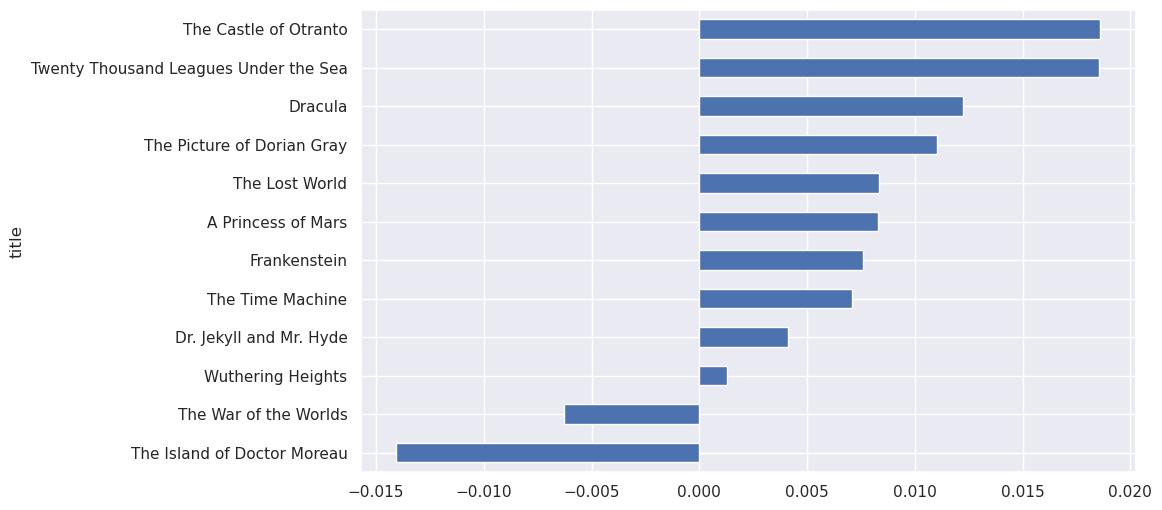

In [71]:
book_sentiment.set_index('title')['polarity'].sort_values().plot.barh(figsize=(10, 6))

<Axes: ylabel='title'>

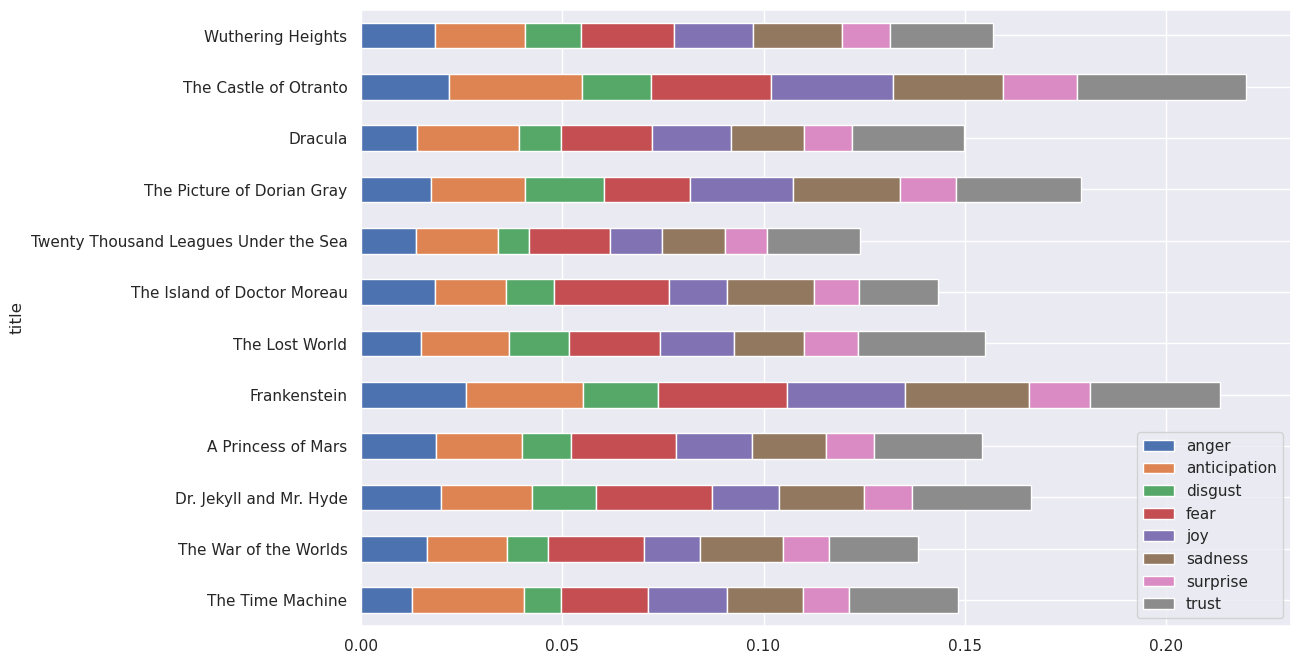

In [72]:
book_sentiment.set_index('title')[emo_cols].plot.barh(figsize=(12, 8), stacked=True)

# Sentiment by Chapter (Example: Dracula)

In [73]:
def plot_chapter_sentiment(book_id, title):
    chap_sent = TOKEN.loc[book_id].groupby('chapter')[['polarity']].mean()
    chap_sent['polarity'].plot(figsize=(15, 4), title=f'{title} — Polarity by Chapter')

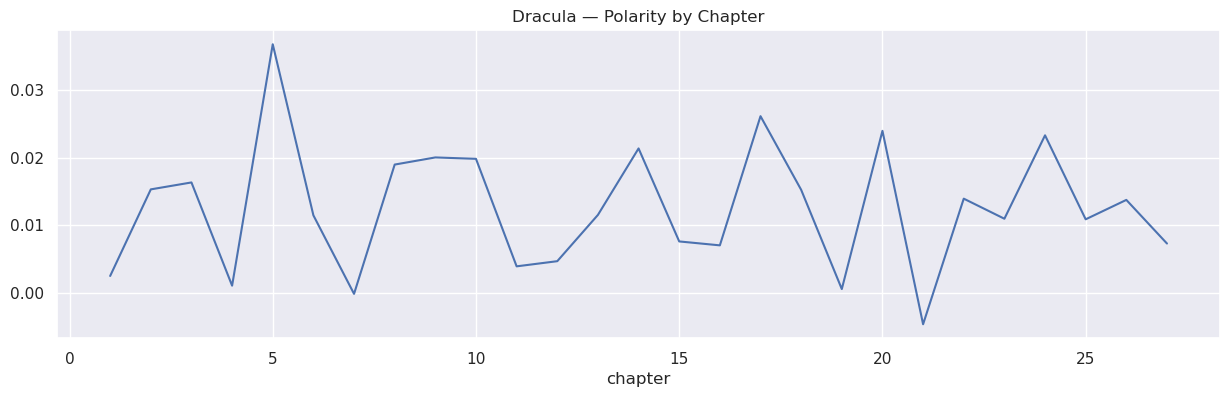

In [74]:
plot_chapter_sentiment(345, 'Dracula')

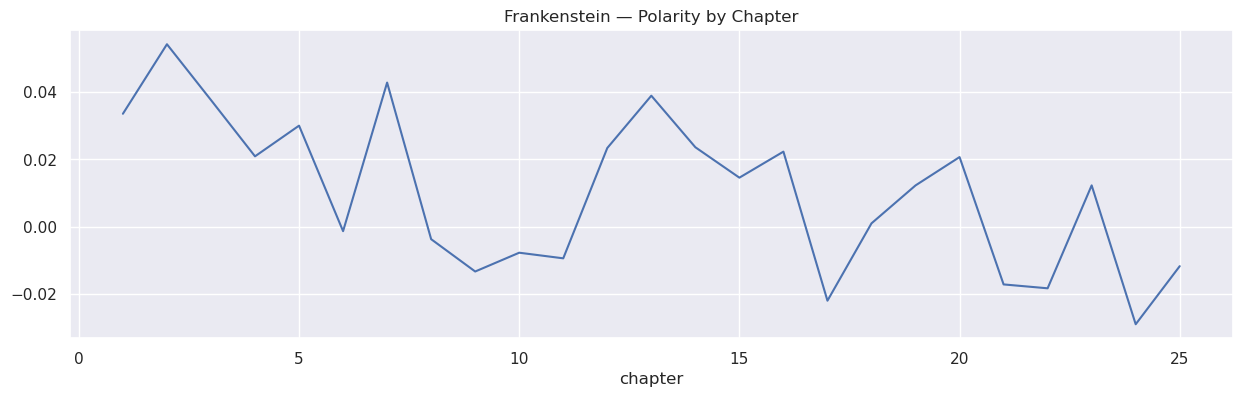

In [75]:
plot_chapter_sentiment(84, 'Frankenstein')

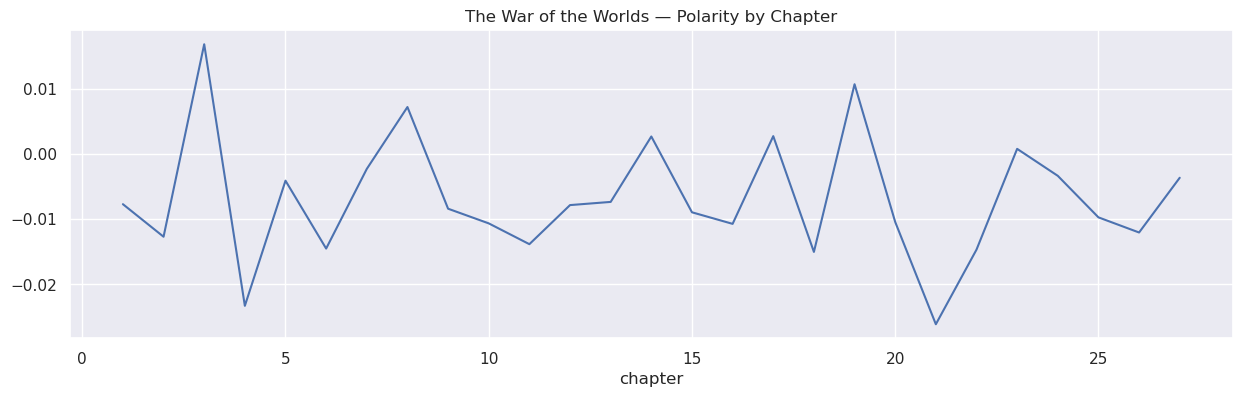

In [76]:
plot_chapter_sentiment(36, 'The War of the Worlds')

# Document-Level Sentiment Table

Sentiment polarity and emotions for each document, as required by the project spec.

In [77]:
DOC_SENTIMENT = TOKEN.groupby('book_id')[emo_cols + sent_cols + ['polarity']].mean()
DOC_SENTIMENT = DOC_SENTIMENT.join(LIBRARY[['title', 'genre']])
DOC_SENTIMENT

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,negative,positive,polarity,title,genre
book_id,,,,,,,,,,,,,
35,0.012755,0.027881,0.009027,0.021658,0.019686,0.018793,0.011461,0.026926,0.035891,0.042977,0.007086,The Time Machine,SciFi
36,0.016532,0.019862,0.010056,0.023908,0.013902,0.020695,0.011421,0.022076,0.042022,0.035729,-0.006293,The War of the Worlds,SciFi
42,0.019870,0.022659,0.015983,0.028824,0.016572,0.020931,0.012095,0.029374,0.042882,0.047006,0.004123,Dr. Jekyll and Mr. Hyde,Gothic
62,0.018776,0.021296,0.012021,0.026153,0.018973,0.018366,0.011748,0.026851,0.040223,0.048526,0.008303,A Princess of Mars,SciFi
84,0.026049,0.029027,0.018759,0.032031,0.029321,0.030789,0.015088,0.032271,0.052353,0.059963,0.007611,Frankenstein,Gothic
139,0.014930,0.021782,0.015023,0.022675,0.018196,0.017369,0.013584,0.031313,0.040871,0.049216,0.008345,The Lost World,SciFi
159,0.018474,0.017637,0.011921,0.028443,0.014500,0.021448,0.011386,0.019566,0.048543,0.034461,-0.014082,The Island of Doctor Moreau,SciFi
164,0.013850,0.020303,0.007756,0.020099,0.012693,0.015755,0.010467,0.022947,0.033103,0.051628,0.018525,Twenty Thousand Leagues Under the Sea,SciFi
174,0.017431,0.023388,0.019518,0.021327,0.025627,0.026589,0.013813,0.031206,0.043286,0.054303,0.011018,The Picture of Dorian Gray,Gothic


# Save Outputs

In [78]:
TOKEN.to_csv(os.path.join(output_dir, 'TOKEN.csv'))
print(f'Saved TOKEN.csv ({len(TOKEN):,} rows)')

Saved TOKEN.csv (871,168 rows)


In [79]:
VOCAB.to_csv(os.path.join(output_dir, 'VOCAB.csv'))
print(f'Saved VOCAB.csv ({len(VOCAB):,} rows)')

Saved VOCAB.csv (25,122 rows)


In [80]:
DOC_SENTIMENT.to_csv(os.path.join(output_dir, 'DOC_SENTIMENT.csv'))
print('Saved DOC_SENTIMENT.csv')

Saved DOC_SENTIMENT.csv


# Summary

- Added stopword flags, Porter stems, and WordNet lemmas to VOCAB and TOKEN.
- Joined NRC Emotion Lexicon (8 emotions + positive/negative + polarity) to VOCAB and TOKEN.
- Built DOC_SENTIMENT table with per-book emotion/polarity averages.
- Visualized sentiment by book and by chapter.

**Next:** Step 4 — TFIDF & Vector Space (F4).